In [94]:
# ============================================================
# LIBRARIES + CONFIGURATION
# ============================================================

# Core data handling
import numpy as np
import pandas as pd
import pyreadstat

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical analysis
import statsmodels.api as sm
from scipy.stats import chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor

# scikit-learn preprocessing and modelling
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model validation and tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Model evaluation
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance


# ============================================================
# PLOT CONFIGURATION
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14

In [95]:
# ============================================================
# LOAD DATA
# ============================================================

# Wave 7
wave7, _ = pyreadstat.read_sav("wave_7_elsa_data.sav")
wave7_ifs, _ = pyreadstat.read_sav("wave_7_ifs_derived_variables.sav")

# Wave 8
wave8, _ = pyreadstat.read_sav("wave_8_elsa_data_eul_v2.sav")
wave8_ifs, _ = pyreadstat.read_sav("wave_8_ifs_derived_variables.sav")

In [96]:
# ============================================================
# CLEAN DATA
# ============================================================

def clean(df):
    df.columns = df.columns.str.lower()
    df.replace([-9, -8, -2, -1], np.nan, inplace=True)
    return df

# Apply cleaning to all datasets
wave7 = clean(wave7)
wave8 = clean(wave8)
wave7_ifs = clean(wave7_ifs)
wave8_ifs = clean(wave8_ifs)

In [97]:
# ============================================================
# OUTCOME DEFINITION
# ============================================================

def dep(x):
    if pd.isna(x):
        return np.nan
    return 1 if x >= 4 else 0

# Create binary depression outcomes for Waves 7 and 8
wave7_ifs["dep_w7"] = wave7_ifs["cesd_sc"].apply(dep)
wave8_ifs["dep_w8"] = wave8_ifs["cesd_sc"].apply(dep)

In [98]:
# ============================================================
# MERGE DATASET
# ============================================================

# Merge Wave 7 data with depression outcomes from Waves 7 and 8
df = wave7.merge(
    wave7_ifs[["idauniq", "dep_w7"]],
    on="idauniq"
).merge(
    wave8_ifs[["idauniq", "dep_w8"]],
    on="idauniq"
)

# Retain participants without depression at Wave 7
# and with a valid Wave 8 depression outcome
df = df[df["dep_w7"] == 0]
df = df.dropna(subset=["dep_w8"])

# Define outcome variable
y = df["dep_w8"]

In [99]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Functional limitation score
df["functional_limitation_score"] = df[
    ['hemobwa','hemobsi','hemobch','hemobcs','hemobcl',
     'hemobst','hemobre','hemobpu','hemobli','hemobpi']
].sum(axis=1)

# Chronic disease count
df["chronic_disease_count"] = df[
    ['hediblu','hedibas','hedibar','hedibos','hedibca',
     'hedibpd','hedibps','hedibad','hedibde','hedibbl','hedibms']
].sum(axis=1)

# Diet score
df["diet_score"] = df["scfru"] + df["scveg"]

# Smoking status
df["smoker"] = (df["heska"] == 1).astype(int)

# Poor sleep
df["poor_sleep"] = (df["pscedc"] == 1).astype(int)

# Reverse-code physical activity variables
for col in ["heacta", "heactb", "heactc"]:
    df[col] = 5 - df[col]

# Physical activity score
df["physical_activity_score"] = (
    df["heacta"] +
    df["heactb"] +
    df["heactc"]
)

In [100]:
# ============================================================
# FEATURE SET
# ============================================================

# Define predictor variables
features = [
    "functional_limitation_score",
    "chronic_disease_count",
    "diet_score",
    "physical_activity_score",
    "smoker",
    "scako",
    "poor_sleep",
    "scfeele",
    "scfrdh",
    "scorg06",
    "couple",
    "iafcon",
    "indsex",
    "indager"
]

# Create predictor dataset
X = df[features]

# One-hot encode categorical predictors
X = pd.get_dummies(
    X,
    columns=["couple", "iafcon"],
    drop_first=True
)

In [101]:
# ============================================================
# LABEL MAPS
# ============================================================

# Labels for encoded model features
label_map = {
    "scfrdh": "Meeting friends frequency",
    "scorg06": "Social club membership",
    "diet_score": "Diet score",
    "scako": "Alcohol consumption frequency",
    "scfeele": "Loneliness frequency",
    "physical_activity_score": "Physical activity score",
    "chronic_disease_count": "Chronic disease count",
    "functional_limitation_score": "Functional limitation score",
    "smoker": "Smoking status",
    "poor_sleep": "Poor sleep",
    "indsex": "Sex",
    "indager": "Age",

    # Relationship status
    "couple_2.0": "Cohabiting (vs married)",
    "couple_3.0": "Not partnered (vs married)",

    # Financial situation
    "iafcon_2.0": "Financial: manage quite well (vs very well)",
    "iafcon_3.0": "Financial: get by alright (vs very well)",
    "iafcon_4.0": "Financial: do not manage well (vs very well)",
    "iafcon_5.0": "Financial: some difficulty (vs very well)",
    "iafcon_6.0": "Financial: severe difficulty (vs very well)"
}

# Labels for original predictor variables
display_label_map = {
    "functional_limitation_score": "Functional limitation score",
    "chronic_disease_count": "Chronic disease count",
    "physical_activity_score": "Physical activity score",
    "diet_score": "Diet score",
    "smoker": "Smoking status",
    "scako": "Alcohol consumption frequency",
    "poor_sleep": "Poor sleep",
    "scfeele": "Loneliness frequency",
    "scfrdh": "Meeting friends frequency",
    "scorg06": "Social club membership",
    "couple": "Relationship status",
    "iafcon": "Financial situation",
    "indsex": "Sex",
    "indager": "Age",
    "erfvoft": "Volunteering frequency"
}

In [102]:
# ============================================================
# SAMPLE CHARACTERISTICS
# ============================================================

# Analytical cohort
# Participants without depression at Wave 7
# and with a valid Wave 8 depression outcome
df_eligible = df.copy()

n_total = len(df_eligible)
n_depression = int(df_eligible["dep_w8"].sum())
n_no_depression = n_total - n_depression

depression_pct = (
    n_depression / n_total * 100
)

no_depression_pct = (
    n_no_depression / n_total * 100
)

print("=" * 50)
print("ANALYTICAL COHORT")
print("=" * 50)

print(f"Total sample: {n_total:,}")
print(
    f"No depression at Wave 8: "
    f"{n_no_depression:,} ({no_depression_pct:.1f}%)"
)
print(
    f"New depression cases at Wave 8: "
    f"{n_depression:,} ({depression_pct:.1f}%)"
)

# Complete-case sample
# Excluding volunteering frequency
key_vars = [
    "functional_limitation_score",
    "chronic_disease_count",
    "diet_score",
    "physical_activity_score",
    "smoker",
    "scako",
    "poor_sleep",
    "scfeele",
    "scfrdh",
    "scorg06",
    "couple",
    "iafcon",
    "indsex",
    "indager"
]

df_cc = df_eligible.dropna(
    subset=key_vars
).copy()

print(
    f"Complete-case sample size: "
    f"{len(df_cc):,}"
)

# Numerical descriptive statistics
print("\n" + "=" * 50)
print("NUMERICAL VARIABLES")
print("=" * 50)

continuous_summary = pd.DataFrame({
    "Variable": [
        "Age",
        "Functional limitation score",
        "Chronic disease count",
        "Physical activity score",
        "Diet score",
        "Alcohol consumption frequency",
        "Loneliness frequency",
        "Meeting friends frequency"
    ],
    "Mean": [
        df_eligible["indager"].mean(),
        df_eligible["functional_limitation_score"].mean(),
        df_eligible["chronic_disease_count"].mean(),
        df_eligible["physical_activity_score"].mean(),
        df_eligible["diet_score"].mean(),
        df_eligible["scako"].mean(),
        df_eligible["scfeele"].mean(),
        df_eligible["scfrdh"].mean()
    ],
    "SD": [
        df_eligible["indager"].std(),
        df_eligible["functional_limitation_score"].std(),
        df_eligible["chronic_disease_count"].std(),
        df_eligible["physical_activity_score"].std(),
        df_eligible["diet_score"].std(),
        df_eligible["scako"].std(),
        df_eligible["scfeele"].std(),
        df_eligible["scfrdh"].std()
    ]
}).round(3)

print(continuous_summary)

# Categorical descriptive statistics
print("\n" + "=" * 50)
print("CATEGORICAL VARIABLES")
print("=" * 50)

def categorical_summary(df, var, labels):
    counts = (
        df[var]
        .value_counts(dropna=False)
        .sort_index()
    )

    percents = (
        df[var]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .sort_index() * 100
    )

    summary = pd.DataFrame({
        "Category": counts.index.map(labels),
        "n": counts.values,
        "%": percents.values
    })

    return summary.round(2)

# Category labels
sex_labels = {
    1: "Male",
    2: "Female"
}

relationship_labels = {
    1.0: "Married",
    2.0: "Cohabiting",
    3.0: "Not partnered"
}

financial_labels = {
    1.0: "Manage very well",
    2.0: "Manage quite well",
    3.0: "Get by alright",
    4.0: "Do not manage very well",
    5.0: "Some financial difficulties",
    6.0: "Severe financial difficulties"
}

binary_labels = {
    0: "No",
    1: "Yes"
}

# Binary and nominal variables
print("\nSex")
print(
    categorical_summary(
        df_eligible,
        "indsex",
        sex_labels
    )
)

print("\nRelationship status")
print(
    categorical_summary(
        df_eligible,
        "couple",
        relationship_labels
    )
)

print("\nFinancial situation")
print(
    categorical_summary(
        df_eligible,
        "iafcon",
        financial_labels
    )
)

print("\nSmoking status")
print(
    categorical_summary(
        df_eligible,
        "smoker",
        binary_labels
    )
)

print("\nPoor sleep")
print(
    categorical_summary(
        df_eligible,
        "poor_sleep",
        binary_labels
    )
)

print("\nSocial club membership")
print(
    categorical_summary(
        df_eligible,
        "scorg06",
        binary_labels
    )
)

# Alcohol consumption frequency
alcohol_labels = {
    1: "Almost every day",
    2: "Five or six days a week",
    3: "Three or four days a week",
    4: "Once or twice a week",
    5: "Once or twice a month",
    6: "Once every couple of months",
    7: "Once or twice a year",
    8: "Not at all in the last 12 months"
}

alcohol_table = (
    df[df["scako"] > 0]["scako"]
    .map(alcohol_labels)
    .value_counts(sort=False)
    .rename_axis("Category")
    .reset_index(name="Frequency")
)

alcohol_table["Percentage"] = (
    alcohol_table["Frequency"] /
    alcohol_table["Frequency"].sum() *
    100
).round(1)

print("\nAlcohol consumption frequency")
print(alcohol_table)

# Loneliness frequency
loneliness_labels = {
    1: "Hardly ever or never",
    2: "Some of the time",
    3: "Often"
}

loneliness_table = (
    df[df["scfeele"] > 0]["scfeele"]
    .map(loneliness_labels)
    .value_counts(sort=False)
    .rename_axis("Category")
    .reset_index(name="Frequency")
)

loneliness_table["Percentage"] = (
    loneliness_table["Frequency"] /
    loneliness_table["Frequency"].sum() *
    100
).round(1)

print("\nLoneliness frequency")
print(loneliness_table)

# Frequency of meeting friends
friends_labels = {
    1: "Three or more times a week",
    2: "Once or twice a week",
    3: "Once or twice a month",
    4: "Every few months",
    5: "Once or twice a year",
    6: "Less than once a year or never"
}

friends_table = (
    df[df["scfrdh"] > 0]["scfrdh"]
    .map(friends_labels)
    .value_counts(sort=False)
    .rename_axis("Category")
    .reset_index(name="Frequency")
)

friends_table["Percentage"] = (
    friends_table["Frequency"] /
    friends_table["Frequency"].sum() *
    100
).round(1)

print("\nFrequency of meeting friends")
print(friends_table)

ANALYTICAL COHORT
Total sample: 6,702
No depression at Wave 8: 6,219 (92.8%)
New depression cases at Wave 8: 483 (7.2%)
Complete-case sample size: 5,065

NUMERICAL VARIABLES
                        Variable    Mean      SD
0                            Age  66.067  11.333
1    Functional limitation score   1.457   2.201
2          Chronic disease count   0.121   0.368
3        Physical activity score   9.049   2.295
4                     Diet score   5.280   2.334
5  Alcohol consumption frequency   4.276   2.140
6           Loneliness frequency   1.244   0.480
7      Meeting friends frequency   2.544   1.070

CATEGORICAL VARIABLES

Sex
  Category     n      %
0     Male  3050  45.51
1   Female  3652  54.49

Relationship status
        Category     n      %
0        Married  4578  68.31
1     Cohabiting   444   6.62
2  Not partnered  1680  25.07

Financial situation
                        Category     n      %
0               Manage very well  2968  44.29
1              Manage quite wel


MISSING DATA SUMMARY
                     Variable  Missing n  Missing (%)
       Volunteering frequency       4035         60.2
    Meeting friends frequency        923         13.8
       Social club membership        754         11.3
                   Diet score        656          9.8
Alcohol consumption frequency        588          8.8
         Loneliness frequency        564          8.4
          Financial situation        391          5.8
                   Poor sleep          0          0.0
               Smoking status          0          0.0
        Chronic disease count          0          0.0
      Physical activity score          3          0.0
  Functional limitation score          0          0.0
          Relationship status          0          0.0
                          Sex          0          0.0
                          Age          0          0.0


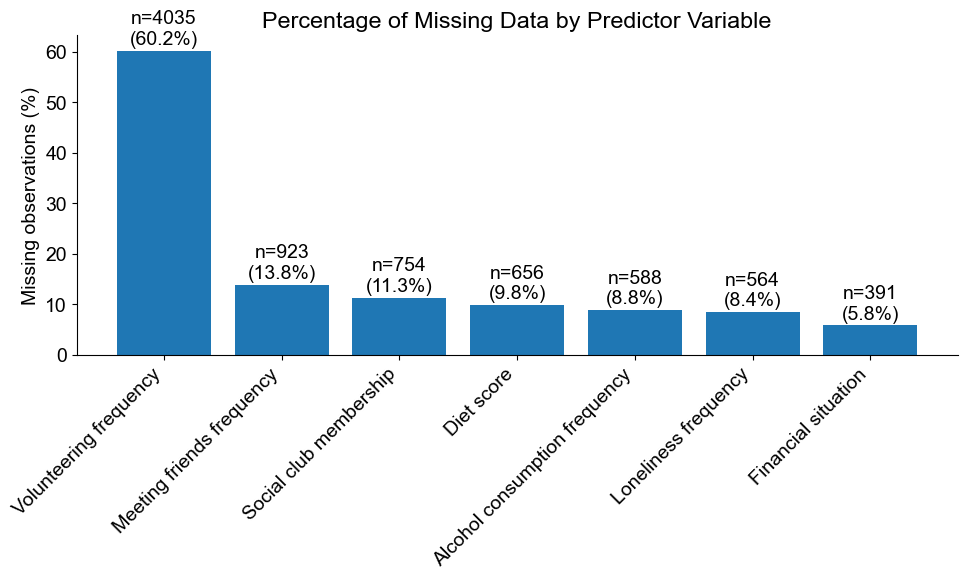

In [103]:
# ============================================================
# MISSING DATA
# ============================================================

# Define variables included in the missing data assessment
missing_vars = [
    "functional_limitation_score",
    "chronic_disease_count",
    "physical_activity_score",
    "diet_score",
    "smoker",
    "scako",
    "poor_sleep",
    "scfeele",
    "scfrdh",
    "scorg06",
    "erfvoft",
    "couple",
    "iafcon",
    "indsex",
    "indager"
]

# Calculate missing counts and percentages for all variables
missing_summary = pd.DataFrame({
    "Variable": [display_label_map.get(var, var) for var in missing_vars],
    "Missing n": [df[var].isnull().sum() for var in missing_vars],
    "Missing (%)": [df[var].isnull().mean() * 100 for var in missing_vars]
})

# Round percentages and sort by missingness
missing_summary["Missing (%)"] = missing_summary["Missing (%)"].round(1)

missing_summary = missing_summary.sort_values(
    "Missing (%)",
    ascending=False
).reset_index(drop=True)

# Display missingness for all variables
print("\nMISSING DATA SUMMARY")
print(missing_summary.to_string(index=False))

# Keep variables with any missing data for the figure
plot_data = missing_summary[missing_summary["Missing (%)"] > 0].copy()

plt.figure(figsize=(10, 6))
plt.title("Percentage of Missing Data by Predictor Variable")

bars = plt.bar(
    plot_data["Variable"],
    plot_data["Missing (%)"]
)

# Add n and % above each bar
for bar, n, pct in zip(
    bars,
    plot_data["Missing n"],
    plot_data["Missing (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"n={n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=mpl.rcParams["font.size"]
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing observations (%)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

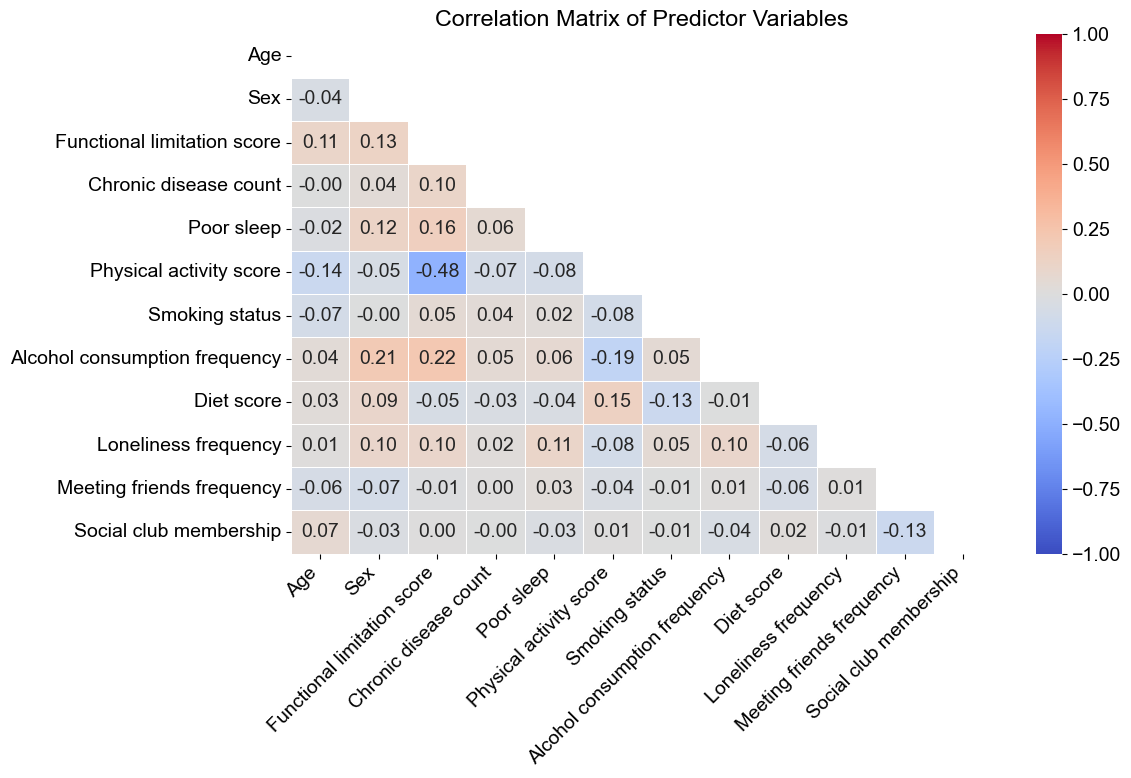


CORRELATION MATRIX FOR ALL PREDICTORS

                                 Age    Sex  Functional limitation score  Chronic disease count  Poor sleep  Physical activity score  Smoking status  Alcohol consumption frequency  Diet score  Loneliness frequency  Meeting friends frequency  Social club membership  Married  Cohabiting  Not partnered  Manage very well  Manage quite well  Get by alright  Do not manage very well  Some financial difficulties  Severe financial difficulties
Age                            1.000 -0.042                        0.108                 -0.004      -0.019                   -0.140          -0.072                          0.038       0.029                 0.008                     -0.055                   0.068   -0.054      -0.111          0.121             0.035              0.022          -0.037                   -0.030                       -0.058                         -0.006
Sex                           -0.042  1.000                        0.125          

In [104]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Define variables for correlation heatmap
# ------------------------------------------------------------

corr_vars = [
    # Sociodemographic
    "indager",
    "indsex",

    # Health
    "functional_limitation_score",
    "chronic_disease_count",
    "poor_sleep",

    # Behavioural
    "physical_activity_score",
    "smoker",
    "scako",
    "diet_score",

    # Social
    "scfeele",
    "scfrdh",
    "scorg06"
]


# ------------------------------------------------------------
# 2. Calculate correlations for heatmap
# ------------------------------------------------------------

corr_named = (
    df[corr_vars]
    .rename(columns=display_label_map)
    .corr()
)


# ------------------------------------------------------------
# 3. Create upper-triangle mask
# ------------------------------------------------------------

mask = np.triu(
    np.ones_like(corr_named, dtype=bool)
)


# ------------------------------------------------------------
# 4. Create correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))
plt.title("Correlation Matrix of Predictor Variables")

sns.heatmap(
    corr_named,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Create dummy variables for all categories
# ------------------------------------------------------------

corr_df = df.copy()

# Relationship status
corr_df["Married"] = (corr_df["couple"] == 1).astype(int)
corr_df["Cohabiting"] = (corr_df["couple"] == 2).astype(int)
corr_df["Not partnered"] = (corr_df["couple"] == 3).astype(int)

# Financial situation
corr_df["Manage very well"] = (corr_df["iafcon"] == 1).astype(int)
corr_df["Manage quite well"] = (corr_df["iafcon"] == 2).astype(int)
corr_df["Get by alright"] = (corr_df["iafcon"] == 3).astype(int)
corr_df["Do not manage very well"] = (corr_df["iafcon"] == 4).astype(int)
corr_df["Some financial difficulties"] = (corr_df["iafcon"] == 5).astype(int)
corr_df["Severe financial difficulties"] = (corr_df["iafcon"] == 6).astype(int)


# ------------------------------------------------------------
# 6. Define all predictors
# ------------------------------------------------------------

all_predictors = corr_vars + [
    "Married",
    "Cohabiting",
    "Not partnered",
    "Manage very well",
    "Manage quite well",
    "Get by alright",
    "Do not manage very well",
    "Some financial difficulties",
    "Severe financial difficulties"
]


# ------------------------------------------------------------
# 7. Calculate correlation values for all predictors
# ------------------------------------------------------------

full_corr = (
    corr_df[all_predictors]
    .rename(columns=display_label_map)
    .corr()
)


# ------------------------------------------------------------
# 8. Display correlation values for all predictors
# ------------------------------------------------------------

print("\nCORRELATION MATRIX FOR ALL PREDICTORS\n")

print(
    full_corr
    .round(3)
    .to_string()
)

In [105]:
# ============================================================
# MULTICOLLINEARITY (VIF)
# ============================================================

# Impute missing values for VIF calculation
X_vif = IterativeImputer().fit_transform(X)
X_vif = pd.DataFrame(X_vif, columns=X.columns)

# Calculate VIF for each predictor
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Apply readable feature labels
vif["feature_name"] = vif["feature"].map(label_map).fillna(vif["feature"])

# Exclude dummy variables from displayed table and sort by VIF
vif_display = (
    vif[~vif["feature"].str.contains("couple_|iafcon_", regex=True)]
    .sort_values("VIF", ascending=False)
)

# Display VIF results
print(vif_display[["feature_name", "VIF"]].round(3))

                     feature_name     VIF
11                            Age  21.082
3         Physical activity score  15.644
10                            Sex  10.858
7            Loneliness frequency   8.873
8       Meeting friends frequency   7.245
2                      Diet score   6.895
5   Alcohol consumption frequency   5.981
0     Functional limitation score   1.930
6                      Poor sleep   1.611
9          Social club membership   1.259
4                  Smoking status   1.149
1           Chronic disease count   1.125


In [106]:
# ============================================================
# MODELS
# ============================================================

# Define imputer
imputer = IterativeImputer(random_state=42)

# Logistic Regression
log_model = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest
rf_model = Pipeline([
    ("imputer", imputer),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))
])

# XGBoost
xgb_model = Pipeline([
    ("imputer", imputer),
    ("model", XGBClassifier(eval_metric="logloss"))
])

In [107]:
# ============================================================
# CROSS-VALIDATION + EVALUATION
# ============================================================

# Define stratified five-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate model performance metrics
def evaluate(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "AUROC": roc_auc_score(y_true, y_prob),
        "Sensitivity": tp/(tp+fn),
        "Specificity": tn/(tn+fp),
        "PPV": tp/(tp+fp),
        "NPV": tn/(tn+fn),
        "F1": f1_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_prob)
    }

# Run model using stratified five-fold cross-validation
def run_model(model, X_data, y_data):
    out = []

    for train, test in cv.split(X_data, y_data):
        X_train, X_test = X_data.iloc[train], X_data.iloc[test]
        y_train, y_test = y_data.iloc[train], y_data.iloc[test]

        model.fit(X_train, y_train)
        prob = model.predict_proba(X_test)[:,1]

        out.append(evaluate(y_test, prob))

    return pd.DataFrame(out)

In [108]:
# ============================================================
# MODEL PERFORMANCE
# ============================================================

# Evaluate each model
log_res = run_model(log_model, X, y)
rf_res = run_model(rf_model, X, y)
xgb_res = run_model(xgb_model, X, y)

# Summarise mean performance across cross-validation folds
results = pd.DataFrame({
    "Logistic": log_res.mean(),
    "Random Forest": rf_res.mean(),
    "XGBoost": xgb_res.mean()
})

# Display model performance
print(results)

C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),


             Logistic  Random Forest   XGBoost
AUROC        0.758545       0.726418  0.668244
Sensitivity  0.026997       0.000000  0.053866
Specificity  0.996302       0.999196  0.984724
PPV          0.309740       0.000000  0.222149
NPV          0.929496       0.927878  0.930557
F1           0.049297       0.000000  0.086329
Brier        0.062218       0.064226  0.071567


In [109]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

# Define XGBoost hyperparameter grid
param_grid = {
    "model__max_depth": [3,4,5],
    "model__n_estimators": [100,200]
}

# Perform grid search using AUROC
grid = GridSearchCV(
    xgb_model,
    param_grid,
    cv=3,
    scoring="roc_auc"
)

grid.fit(X, y)

# Display best hyperparameters
print(grid.best_params_)

{'model__max_depth': 3, 'model__n_estimators': 100}


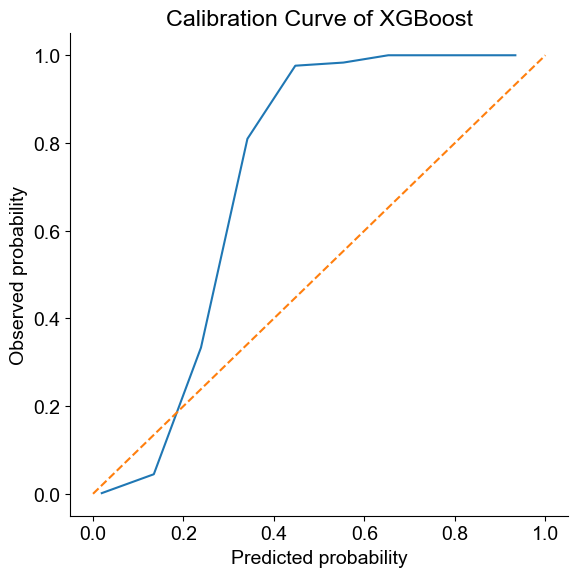

In [110]:
# ============================================================
# CALIBRATION
# ============================================================

# Fit XGBoost model and generate predicted probabilities
xgb_model.fit(X, y)
prob = xgb_model.predict_proba(X)[:, 1]

# Calculate calibration curve
prob_true, prob_pred = calibration_curve(y, prob, n_bins=10)

# Create calibration plot
plt.figure(figsize=(6, 6))

plt.plot(prob_pred, prob_true)
plt.plot([0, 1], [0, 1], "--")

# Format axes
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration Curve of XGBoost")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Display figure
plt.tight_layout()
plt.show()

In [111]:
# ============================================================
# LOGISTIC REGRESSION INTERPRETABILITY ANALYSIS
# ============================================================

# ------------------------------------------------------------
# PREPARE IMPUTED DATA
# ------------------------------------------------------------

X_reset = X.reset_index(drop=True)
y_reset = y.reset_index(drop=True)

X_imp = IterativeImputer(
    random_state=42
).fit_transform(X_reset)

X_imp = pd.DataFrame(
    X_imp,
    columns=X_reset.columns
)

# ------------------------------------------------------------
# FIT FULL MULTIVARIABLE LOGISTIC REGRESSION
# ------------------------------------------------------------

X_sm = sm.add_constant(
    X_imp,
    has_constant="add"
)

logit_model = sm.Logit(
    y_reset,
    X_sm
)

result = logit_model.fit()

# ------------------------------------------------------------
# ADJUSTED ODDS RATIOS + 95% CONFIDENCE INTERVALS
# ------------------------------------------------------------

params = result.params
conf = result.conf_int()

or_df = pd.DataFrame({
    "Variable": params.index,
    "Adjusted Odds Ratio": np.exp(params),
    "CI Lower": np.exp(conf[0]),
    "CI Upper": np.exp(conf[1]),
    "p-value": result.pvalues
})

# Remove intercept
or_df = or_df[
    or_df["Variable"] != "const"
].copy()

# Apply readable variable names
or_df["Variable"] = (
    or_df["Variable"]
    .map(label_map)
    .fillna(or_df["Variable"])
)

# ------------------------------------------------------------
# OVERALL p VALUES FOR MULTI-CATEGORY PREDICTORS
# ------------------------------------------------------------

def matching_columns(
    dataframe,
    exact=None,
    prefix=None
):
    if exact is not None and exact in dataframe.columns:
        return [exact]

    if prefix is not None:
        matches = [
            column
            for column in dataframe.columns
            if column.lower().startswith(prefix.lower())
        ]

        if matches:
            return matches

    return []


predictor_groups = {
    "Relationship status":
        matching_columns(X_imp, prefix="couple"),

    "Financial situation":
        matching_columns(X_imp, prefix="iafcon")
}


def likelihood_ratio_test(
    full_model,
    reduced_model
):
    lr_statistic = 2 * (
        full_model.llf -
        reduced_model.llf
    )

    degrees_freedom = int(
        full_model.df_model -
        reduced_model.df_model
    )

    p_value = chi2.sf(
        lr_statistic,
        degrees_freedom
    )

    return (
        lr_statistic,
        degrees_freedom,
        p_value
    )


overall_rows = []

for predictor, columns_to_remove in predictor_groups.items():

    reduced_columns = [
        column
        for column in X_imp.columns
        if column not in columns_to_remove
    ]

    X_reduced = sm.add_constant(
        X_imp[reduced_columns],
        has_constant="add"
    )

    reduced_model = sm.Logit(
        y_reset,
        X_reduced
    ).fit(disp=False)

    lr_statistic, degrees_freedom, p_value = (
        likelihood_ratio_test(
            result,
            reduced_model
        )
    )

    overall_rows.append({
        "Variable": predictor,
        "LR chi-square": lr_statistic,
        "df": degrees_freedom,
        "Overall p-value": p_value
    })


overall_p_values = pd.DataFrame(
    overall_rows
)

# ------------------------------------------------------------
# OVERALL NAGELKERKE R²
# ------------------------------------------------------------

def nagelkerke_r2(fitted_model):

    n = fitted_model.nobs
    ll_model = fitted_model.llf
    ll_null = fitted_model.llnull

    cox_snell_r2 = 1 - np.exp(
        (2 / n) *
        (ll_null - ll_model)
    )

    max_cox_snell_r2 = 1 - np.exp(
        (2 / n) *
        ll_null
    )

    return (
        cox_snell_r2 /
        max_cox_snell_r2
    )


overall_nagelkerke_r2 = nagelkerke_r2(
    result
)

# ------------------------------------------------------------
# FORMAT p VALUES
# ------------------------------------------------------------

def format_p_value(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "<.001"

    return f"{p:.3f}".lstrip("0")


or_df["p-value"] = (
    or_df["p-value"]
    .apply(format_p_value)
)

overall_p_values["Overall p-value"] = (
    overall_p_values["Overall p-value"]
    .apply(format_p_value)
)

overall_p_values["LR chi-square"] = (
    overall_p_values["LR chi-square"]
    .round(3)
)

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\nADJUSTED ODDS RATIOS AND INDIVIDUAL p VALUES")
print(
    or_df.to_string(
        index=False
    )
)

print("\nOVERALL p VALUES FOR MULTI-CATEGORY PREDICTORS")
print(
    overall_p_values.to_string(
        index=False
    )
)

print("\nOVERALL NAGELKERKE R²")
print(
    round(
        overall_nagelkerke_r2,
        4
    )
)

Optimization terminated successfully.
         Current function value: 0.226143
         Iterations 7

ADJUSTED ODDS RATIOS AND INDIVIDUAL p VALUES
                                    Variable  Adjusted Odds Ratio  CI Lower  CI Upper p-value
                 Functional limitation score             1.180430  1.132750  1.230118   <.001
                       Chronic disease count             1.002491  0.788263  1.274940    .984
                                  Diet score             0.967978  0.925163  1.012775    .159
                     Physical activity score             0.920623  0.878215  0.965078   <.001
                              Smoking status             1.193402  0.891646  1.597281    .235
               Alcohol consumption frequency             1.009208  0.960342  1.060561    .717
                                  Poor sleep             1.687002  1.383195  2.057537   <.001
                        Loneliness frequency             2.567094  2.164330  3.044810   <.001
      

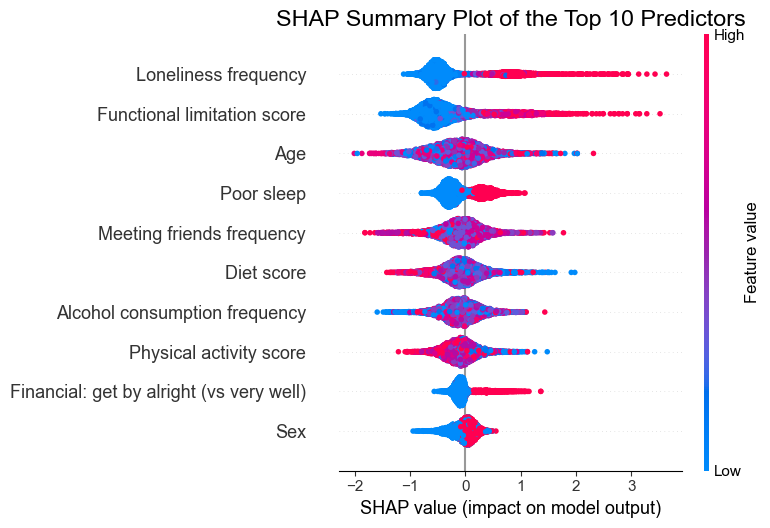


Top SHAP Features
                                    Feature  Mean |SHAP| Value
0                      Loneliness frequency              0.589
1               Functional limitation score              0.570
2                                       Age              0.383
3                                Poor sleep              0.295
4                 Meeting friends frequency              0.289
5                                Diet score              0.276
6             Alcohol consumption frequency              0.260
7                   Physical activity score              0.228
8  Financial: get by alright (vs very well)              0.156
9                                       Sex              0.155


In [112]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

# Impute data for SHAP analysis
imputer = IterativeImputer(random_state=42)

X_imp = imputer.fit_transform(X)
X_imp = pd.DataFrame(X_imp, columns=X.columns)

# Fit XGBoost model
xgb_model.fit(X, y)

model = xgb_model.named_steps["model"]

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_imp)

# Apply readable feature names
X_plot = X_imp.rename(columns=label_map)

# Create SHAP summary plot
plt.figure(figsize=(10, 10))
plt.title("SHAP Summary Plot of the Top 10 Predictors")

shap.summary_plot(
    shap_values,
    X_plot,
    max_display=10,
    show=False
)

plt.tight_layout()
plt.show()

# Calculate mean absolute SHAP values
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns
)

# Apply readable feature names
shap_importance.index = [
    label_map.get(col, col)
    for col in shap_importance.index
]

# Sort by importance
shap_importance = shap_importance.sort_values(
    ascending=False
)

# Create SHAP importance table
shap_table = pd.DataFrame({
    "Feature": shap_importance.index,
    "Mean |SHAP| Value": shap_importance.values
})

# Display top 10 predictors
print("\nTop SHAP Features")
print(shap_table.head(10).round(3))

In [113]:
# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================

# Fit Random Forest model
rf_model.fit(X, y)

# Calculate permutation importance
perm = permutation_importance(
    rf_model,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# Calculate mean importance for each predictor
perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

# Apply readable feature names
perm_importance.index = [
    label_map.get(col, col)
    for col in perm_importance.index
]

# Sort by importance
perm_importance = perm_importance.sort_values(
    ascending=False
)

# Create permutation importance table
perm_table = pd.DataFrame({
    "Feature": perm_importance.index,
    "Permutation Importance": perm_importance.values
})

# Display top 10 predictors
print("\nTop Permutation Features")
print(perm_table.head(10).round(3))


Top Permutation Features
                                    Feature  Permutation Importance
0                      Loneliness frequency                   0.042
1               Functional limitation score                   0.035
2                                Poor sleep                   0.013
3                   Physical activity score                   0.013
4                                       Age                   0.012
5             Alcohol consumption frequency                   0.010
6                                Diet score                   0.006
7  Financial: get by alright (vs very well)                   0.005
8                Not partnered (vs married)                   0.005
9                                       Sex                   0.004


In [114]:
# ============================================================
# DOMAIN MODELS
# ============================================================

# Demographic and socioeconomic domain
demographic_socioeconomic = [
    "indager",
    "indsex",
    "couple_2.0",
    "couple_3.0",
    "iafcon_2.0",
    "iafcon_3.0",
    "iafcon_4.0",
    "iafcon_5.0",
    "iafcon_6.0"
]

# Health domain
health = [
    "functional_limitation_score",
    "chronic_disease_count",
    "poor_sleep"
]

# Behavioural domain
behavioural = [
    "physical_activity_score",
    "smoker",
    "scako",
    "diet_score"
]

# Social domain
social = [
    "scfeele",
    "scfrdh",
    "scorg06"
]

# Define domain-specific predictor sets
domain_models = {
    "Sociodemographic": demographic_socioeconomic,
    "Health": health,
    "Behavioural": behavioural,
    "Social": social
}

# Evaluate domain-specific models
domain_results = {}

for name, cols in domain_models.items():
    res = run_model(xgb_model, X[cols], y)
    domain_results[name] = res.mean()
    print("\n", name)
    print(res.mean())

# Create domain model comparison table
domain_results_df = pd.DataFrame(domain_results)

# Display domain model comparison
print("\nDomain model comparison")
print(domain_results_df)


 Sociodemographic
AUROC          0.561841
Sensitivity    0.008290
Specificity    0.995659
PPV            0.182143
NPV            0.928197
F1             0.015617
Brier          0.070059
dtype: float64


C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),



 Health
AUROC          0.685978
Sensitivity    0.000000
Specificity    0.998874
PPV            0.000000
NPV            0.927856
F1             0.000000
Brier          0.065029
dtype: float64

 Behavioural
AUROC          0.571637
Sensitivity    0.004145
Specificity    0.992604
PPV            0.044444
NPV            0.927712
F1             0.007400
Brier          0.070467
dtype: float64

 Social
AUROC          0.651533
Sensitivity    0.002083
Specificity    0.998071
PPV            0.035714
NPV            0.927942
F1             0.003883
Brier          0.066125
dtype: float64

Domain model comparison
             Sociodemographic    Health  Behavioural    Social
AUROC                0.561841  0.685978     0.571637  0.651533
Sensitivity          0.008290  0.000000     0.004145  0.002083
Specificity          0.995659  0.998874     0.992604  0.998071
PPV                  0.182143  0.000000     0.044444  0.035714
NPV                  0.928197  0.927856     0.927712  0.927942
F1              

C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),


In [115]:
# ============================================================
# SUBGROUP ANALYSIS
# ============================================================

# Create ordered age groups
df["age_group"] = pd.cut(
    df["indager"],
    bins=[50, 60, 70, 80, np.inf],
    labels=["50-59", "60-69", "70-79", "80+"],
    right=False,
    include_lowest=True
)

# ------------------------------------------------------------
# Sex subgroup analysis
# ------------------------------------------------------------

# Define sex labels
sex_labels = {
    1: "Male",
    2: "Female"
}

print("\n" + "=" * 50)
print("SUBGROUP ANALYSIS BY SEX")
print("=" * 50)

sex_results = {}

# Evaluate model performance by sex
for sex_code, sex_label in sex_labels.items():
    idx = df["indsex"] == sex_code

    print(f"\nSex: {sex_label}")
    print(f"Sample size: {idx.sum():,}")
    print(f"New depression rate: {y[idx].mean():.4f} ({y[idx].mean() * 100:.2f}%)")

    res = run_model(xgb_model, X[idx], y[idx]).mean()
    sex_results[sex_label] = res

    print(res)

# Create and display sex subgroup summary
sex_results_df = pd.DataFrame(sex_results).T
print("\nSex subgroup summary:")
print(sex_results_df.round(3))

# ------------------------------------------------------------
# Age subgroup analysis
# ------------------------------------------------------------

print("\n" + "=" * 50)
print("SUBGROUP ANALYSIS BY AGE GROUP")
print("=" * 50)

age_results = {}

# Evaluate model performance by age group
for group in df["age_group"].cat.categories:
    idx = df["age_group"] == group

    print(f"\nAge group: {group}")
    print(f"Sample size: {idx.sum():,}")
    print(f"New depression rate: {y[idx].mean():.4f} ({y[idx].mean() * 100:.2f}%)")

    res = run_model(xgb_model, X[idx], y[idx]).mean()
    age_results[str(group)] = res

    print(res)

# Create and display age subgroup summary
age_results_df = pd.DataFrame(age_results).T
print("\nAge subgroup summary:")
print(age_results_df.round(3))


SUBGROUP ANALYSIS BY SEX

Sex: Male
Sample size: 3,050
New depression rate: 0.0567 (5.67%)
AUROC          0.675293
Sensitivity    0.063697
Specificity    0.988877
PPV            0.221538
NPV            0.946136
F1             0.098258
Brier          0.058448
dtype: float64

Sex: Female
Sample size: 3,652
New depression rate: 0.0849 (8.49%)
AUROC          0.633804
Sensitivity    0.064516
Specificity    0.984741
PPV            0.281987
NPV            0.919029
F1             0.102725
Brier          0.083385
dtype: float64

Sex subgroup summary:
        AUROC  Sensitivity  Specificity    PPV    NPV     F1  Brier
Male    0.675        0.064        0.989  0.222  0.946  0.098  0.058
Female  0.634        0.065        0.985  0.282  0.919  0.103  0.083

SUBGROUP ANALYSIS BY AGE GROUP

Age group: 50-59
Sample size: 1,375
New depression rate: 0.0742 (7.42%)
AUROC          0.689672
Sensitivity    0.068571
Specificity    0.985076
PPV            0.266667
NPV            0.929582
F1             0.10845

In [116]:
# ============================================================
# BASELINE MODEL
# ============================================================

# Define baseline predictors
baseline_features = [
    "physical_activity_score",
    "scfeele",
    "scako"
]

X_base = df[baseline_features]

# Define baseline Logistic Regression model
base_model = Pipeline([
    ("imputer", IterativeImputer(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Evaluate baseline model
base_results = run_model(base_model, X_base, y)

# Display mean performance across cross-validation folds
print(base_results.mean())

AUROC          0.718909
Sensitivity    0.004167
Specificity    0.998714
PPV            0.116667
NPV            0.928124
F1             0.008040
Brier          0.063529
dtype: float64


In [117]:
# ============================================================
# TEMPORAL MODEL
# ============================================================

# Select Wave 8 variables for temporal analysis
wave8_small = wave8[
    ["idauniq", "heacta", "scfeele", "scako"]
].copy()

# Reverse-code Wave 8 physical activity to match Wave 7
wave8_small["heacta"] = 5 - wave8_small["heacta"]

# Merge Wave 7 and Wave 8 data
df_temp = df.merge(wave8_small, on="idauniq", suffixes=("_w7", "_w8"))

# Calculate change scores between Waves 7 and 8
df_temp["heact_change"] = df_temp["heacta_w8"] - df_temp["heacta_w7"]
df_temp["loneliness_change"] = df_temp["scfeele_w8"] - df_temp["scfeele_w7"]
df_temp["alcohol_change"] = df_temp["scako_w8"] - df_temp["scako_w7"]

# Define temporal predictors
temp_features = [
    "heact_change",
    "loneliness_change",
    "alcohol_change"
]

X_temp = df_temp[temp_features]
y_temp = df_temp["dep_w8"]

# Define temporal Logistic Regression model
temp_model = Pipeline([
    ("imputer", IterativeImputer(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Evaluate temporal model
temp_results = run_model(temp_model, X_temp, y_temp)

# Display mean performance across cross-validation folds
print(temp_results.mean())

AUROC          0.578957
Sensitivity    0.000000
Specificity    1.000000
PPV                 NaN
NPV            0.927932
F1             0.000000
Brier          0.065780
dtype: float64


C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),


In [118]:
# ============================================================
# SENSITIVITY ANALYSIS: IMPACT OF REMOVING VOLUNTEERING
# ============================================================

# ------------------------------------------------------------
# 1. Feature set WITHOUT volunteering
# ------------------------------------------------------------

# Use the final modelling dataset directly
X_without_vol = X.copy()

# ------------------------------------------------------------
# 2. Feature set WITH volunteering
# ------------------------------------------------------------

features_with_volunteering = [
    "functional_limitation_score",
    "chronic_disease_count",
    "physical_activity_score",
    "diet_score",
    "smoker",
    "scako",
    "poor_sleep",
    "scfeele",
    "erfvoft",
    "scfrdh",
    "scorg06",
    "couple",
    "iafcon",
    "indsex",
    "indager"
]

X_with_vol = df[features_with_volunteering].copy()

X_with_vol = pd.get_dummies(
    X_with_vol,
    columns=["couple", "iafcon"],
    drop_first=True
)

# ------------------------------------------------------------
# 3. Run models WITH volunteering
# ------------------------------------------------------------

log_with = run_model(log_model, X_with_vol, y)
rf_with = run_model(rf_model, X_with_vol, y)
xgb_with = run_model(xgb_model, X_with_vol, y)

# ------------------------------------------------------------
# 4. Run models WITHOUT volunteering
# ------------------------------------------------------------

log_without = run_model(log_model, X_without_vol, y)
rf_without = run_model(rf_model, X_without_vol, y)
xgb_without = run_model(xgb_model, X_without_vol, y)

# ------------------------------------------------------------
# 5. Compare mean AUROC
# ------------------------------------------------------------

auroc_comparison = pd.DataFrame({
    "With volunteering": [
        log_with["AUROC"].mean(),
        rf_with["AUROC"].mean(),
        xgb_with["AUROC"].mean()
    ],
    "Without volunteering": [
        log_without["AUROC"].mean(),
        rf_without["AUROC"].mean(),
        xgb_without["AUROC"].mean()
    ]
}, index=[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
])

auroc_comparison["Change"] = (
    auroc_comparison["Without volunteering"]
    - auroc_comparison["With volunteering"]
)

print("\nAUROC comparison:")
print(auroc_comparison.round(3))

C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),
C:\Users\udumz\AppData\Local\Temp\ipykernel_15760\3799070978.py:17: RuntimeWarning: invalid value encountered in scalar divide
  "PPV": tp/(tp+fp),



AUROC comparison:
                     With volunteering  Without volunteering  Change
Logistic Regression               0.76                 0.759  -0.001
Random Forest                     0.73                 0.726  -0.003
XGBoost                           0.68                 0.668  -0.011
